https://www.kaggle.com/competitions/ml-intensive-yandex-academy-spring-2025

In [19]:
!pip install torch-summary
!pip install torchsampler

In [20]:
# import shutil
# import os
# import pandas as pd
# from collections import Counter

# src_dir = '/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/img_train'
# dst_dir = '/kaggle/working/img_train_rare_only'
# os.makedirs(dst_dir, exist_ok=True)

# df = pd.read_csv('/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/train_answers.csv')
# class_counts = Counter(df["target_feature"])
# rare_classes = [cls for cls, count in class_counts.items() if cls >= 1 and count < 1000]

# rare_ids = df[df["target_feature"].isin(rare_classes)]["img_id"]

# for img_id in rare_ids:
#     filename = f"{img_id}.jpg"
#     src = os.path.join(src_dir, filename)
#     dst = os.path.join(dst_dir, filename)
#     if os.path.exists(src):
#         shutil.copy(src, dst)

In [21]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [22]:
import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class Human_Poses_Data(Dataset):
    def __init__(self, image_dir, csv_dir=None, transform=None, train=False):
        self.image_dir = image_dir 
        self.data = sorted(os.listdir(image_dir))
        self.transform = transform
        self.train = train
        if self.train:
            train_answers = pd.read_csv(csv_dir)
            self.labels = dict(zip(train_answers["img_id"].values, train_answers["target_feature"].values))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path_to_image = os.path.join(self.image_dir, self.data[idx])
        image = Image.open(path_to_image).convert("RGB")

        if self.transform:
            image = self.transform(image)

        img_id = int(os.path.splitext(self.data[idx])[0]) # '17363.jpg' → 17363
        if self.train:
            label = self.labels[img_id]
            return image, label
        else:
            return image, img_id

    def get_labels(self):
        return [self.labels[int(os.path.splitext(img_name)[0])] for img_name in self.data]

from torch.utils.data import ConcatDataset

class ConcatWithLabels(ConcatDataset):
    def __init__(self, datasets):
        super().__init__(datasets)
        # Устанавливаем атрибут imgs, чтобы ImbalancedDatasetSampler мог его использовать
        self.imgs = self.get_labels()
    
    def get_labels(self):
        all_labels = []
        for dataset in self.datasets:
            # Каждая часть датасета должна иметь метод get_labels()
            all_labels.extend(dataset.get_labels())
        return all_labels

In [23]:
from torchvision.transforms import ToTensor
from torchvision import transforms
from torch.utils.data import ConcatDataset
from torch.utils.data import random_split

rare_aug_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ], p=0.5),
    transforms.RandomAffine(
        degrees=15,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
        interpolation=transforms.InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),  # было PIL
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),  # теперь Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


rare_augmented_data = Human_Poses_Data(
    image_dir='/kaggle/working/img_train_rare_only',
    csv_dir='/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/train_answers.csv',
    transform=rare_aug_transform,
    train=True
) # для редких классов у которых меньше 1000 изображений

train_augmentation = transforms.Compose([
    transforms.Resize((224, 224), transforms.InterpolationMode.LANCZOS), # Lanczos наиболее точный                
    transforms.RandomHorizontalFlip(p=0.5), # переворачиваем горизонтально с вероятностью 50%
    transforms.RandomRotation(degrees=10), # рандомно поворачиваем на 10 градусов
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # brightness - просто меняет яркость, сontrast - белые пиксели приближает к белым, а черные к черным и тд.
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # взято с моделей для Imagenet
])

test_dw = transforms.Compose([
    transforms.Resize((224, 224), transforms.InterpolationMode.LANCZOS), # Lanczos наиболее точный                
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # взято с моделей для Imagenet
])

augmented_training_data = Human_Poses_Data(
    image_dir='/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/img_train',
    csv_dir='/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/train_answers.csv',
    transform=train_augmentation,
    train=True
)# для обучения

train_data_basic = Human_Poses_Data(
    image_dir='/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/img_train',
    csv_dir='/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/train_answers.csv',
    transform=test_dw,
    train=True
) # для обучения

train_data = ConcatWithLabels([train_data_basic, augmented_training_data, rare_augmented_data]) # объединяем данные

test_data = Human_Poses_Data(
    image_dir='/kaggle/input/ml-intensive-yandex-academy-spring-2025/human_poses_data/img_test',
    transform=test_dw,
    train=False
)# для тестинга

train_set, valid_set = random_split(train_data, (0.8, 0.2))

train_set.imgs = [train_data.imgs[i] for i in train_set.indices]
valid_set.imgs = [train_data.imgs[i] for i in valid_set.indices]

len(train_set), len(valid_set) # обучаемая выборка теперь в 2 раза больше.

(25349, 6337)

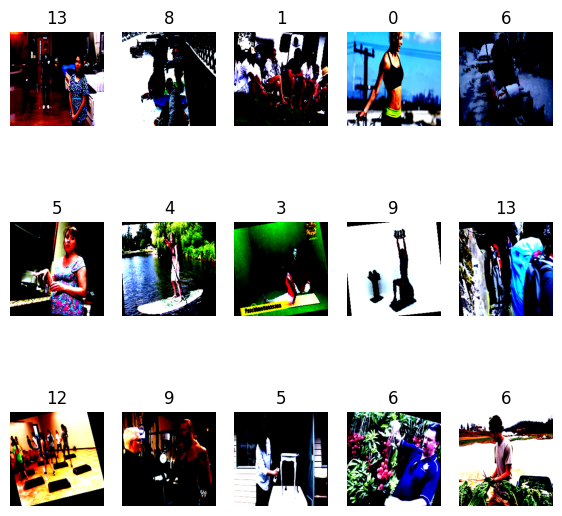

In [24]:
import matplotlib.pyplot as plt

def visualize(data): # визуализируем датасет
  fig = plt.figure(figsize=(7, 7))

  cols, rows = 5, 3

  for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(data), size=(1,)).item() # рандомная картинка
    img, label = data[sample_idx]

    fig.add_subplot(rows, cols, i)

    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))

  plt.show()

visualize(train_set) # визуализация

In [25]:
from torch import nn
# размер изображения должен быть 224x224
class ResBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    self.relu = nn.ReLU()
    self.model = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels)
    )
    if in_channels != out_channels or stride > 1:
        self.conv_downsample = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
            nn.BatchNorm2d(out_channels)
        )
    else:
        self.conv_downsample = nn.Identity()

  def forward(self, x):
    out = self.model(x)
    return self.relu(out + self.conv_downsample(x))

class ResNet34(nn.Module):
  def __init__(self, num_of_classes=20):
    super().__init__()

    self.model = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
        nn.BatchNorm2d(64), # [64, 112, 112]
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1), #[64, 56, 56]
        # 1 x3
        ResBlock(64, 64), # [64, 56, 56]
        ResBlock(64, 64), # [64, 56, 56]
        ResBlock(64, 64),
        # 2 x4
        ResBlock(64, 128, stride=2), #[128, 28, 28]
        ResBlock(128, 128), # [128, 28, 28]
        ResBlock(128, 128),
        ResBlock(128, 128),
        # 3 x6
        ResBlock(128, 256, stride=2), # [256, 14, 14]
        ResBlock(256, 256), 
        ResBlock(256, 256),
        ResBlock(256, 256),
        ResBlock(256, 256),
        ResBlock(256, 256),
        # 4 x3
        ResBlock(256, 512, stride=2), # [512, 7, 7]
        ResBlock(512, 512),
        ResBlock(512, 512),

        nn.AdaptiveAvgPool2d((1, 1)), # [512, 1, 1]
        nn.Flatten(),
        nn.Linear(512, num_of_classes)
    )

  def forward(self, x):
    return self.model(x)

from torchsummary import summary

model = ResNet34().to(device)
summary(model, input_size=(3, 224, 224))

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2d: 2-1                       9,472
|    └─BatchNorm2d: 2-2                  128
|    └─ReLU: 2-3                         --
|    └─MaxPool2d: 2-4                    --
|    └─ResBlock: 2-5                     --
|    |    └─ReLU: 3-1                    --
|    |    └─Sequential: 3-2              74,112
|    |    └─Identity: 3-3                --
|    └─ResBlock: 2-6                     --
|    |    └─ReLU: 3-4                    --
|    |    └─Sequential: 3-5              74,112
|    |    └─Identity: 3-6                --
|    └─ResBlock: 2-7                     --
|    |    └─ReLU: 3-7                    --
|    |    └─Sequential: 3-8              74,112
|    |    └─Identity: 3-9                --
|    └─ResBlock: 2-8                     --
|    |    └─ReLU: 3-10                   --
|    |    └─Sequential: 3-11             221,952
|    |    └─Sequential: 3-12             8,576
|  

In [26]:
from IPython.display import clear_output

def show_loss(test_losses, test_f1_scores):
  clear_output()

  plt.figure(figsize=(15,15))

  plt.subplot(2, 2, 1)
  plt.title('Test Loss')
  plt.plot(np.arange(len(test_losses)), test_losses)  # лосс обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 3)
  plt.title('Test F1 score')
  plt.plot(np.arange(len(test_f1_scores)), test_f1_scores) # accuracy обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.show()


In [27]:
!pip install pytorch-ignite

In [28]:
from torch import optim
from torch.utils.data import DataLoader
from torchsampler import ImbalancedDatasetSampler

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)  # регуляризация

criterion = nn.CrossEntropyLoss()


# Dataloaders
# разделим данные на батчи

from torch import optim
from torch.utils.data import DataLoader

batch_size = 128
num_of_epochs = 100


train_labels = [train_data.imgs[i] for i in train_set.indices]


num_workers = min(8, os.cpu_count()) # для многопоточности

train_loader = DataLoader(train_set, batch_size=batch_size, sampler=ImbalancedDatasetSampler(train_set, labels=train_labels), num_workers=num_workers, pin_memory=True) # обучающая выборка
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True) # обучающая выборка
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True) # тестовая выборка

# persistent_workers позволяет переиспользовать потоки
# pinned_memory позволяет использовать область памяти ОЗУ которая не выгружает ее в диск
# prefetch_factor позволяет во время каждой загрузки, предзагружать еще 4 батча

In [29]:
from ignite.engine import create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, Precision, Recall, Fbeta
from ignite.handlers import ModelCheckpoint

from ignite.engine import Events

trainer = create_supervised_trainer(
    model, 
    optimizer, 
    criterion, 
    device
)

metrics = {
    "f1_score": Fbeta(average=True, beta=1.0),
    "loss": Loss(criterion)
}

train_evaluator = create_supervised_evaluator(model, metrics, device)
test_evaluator = create_supervised_evaluator(model, metrics, device)

# check_pointer = ModelCheckpoint(
#     dirname="checkpoints",
#     filename_prefix="ResNet34",
#     n_saved=5, # хранит только 5 чекпоинтов
#     require_empty=False, 
#     create_dir=True,
#     atomic=True # файлы гарантированно не будут повреждены
# )

# to_save = {
#     "model": model,
#     "optimizer": optimizer,
#     "trainer": trainer
# }

# trainer.add_event_handler(Events.EPOCH_COMPLETED, check_pointer, to_save)

In [30]:
train_losses = []
test_losses = []

train_f1_scores = []
test_f1_scores = []

def compute_epoch_results(engine):
   # train_evaluator.run(train_loader)
    test_evaluator.run(valid_loader)
    # Сохраняем метрики
   # train_losses.append(train_evaluator.state.metrics["loss"])
    test_losses.append(test_evaluator.state.metrics["loss"])
   # train_f1_scores.append(train_evaluator.state.metrics["f1_score"])
    test_f1_scores.append(test_evaluator.state.metrics["f1_score"])

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)

trainer.add_event_handler(
    Events.EPOCH_COMPLETED(every=10),
    lambda engine: show_loss(test_losses, test_f1_scores)
)


def log_epoch_results(engine, label=""):
    result = ', '.join([f"{m} = {v}" for m, v in engine.state.metrics.items()])
    print(f"{label} Res:", result)

train_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Train")
test_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Test")

@trainer.on(Events.ITERATION_COMPLETED(every=10))
def debug_print(engine):
    print(f"Iteration {engine.state.iteration} done, loss={engine.state.output:.4f}")


def log_batch_distribution(engine):
    batch = engine.state.batch
    # Предположим, что батч выглядит как (inputs, labels)
    inputs, labels = batch
    # Преобразуем labels в numpy и подсчитаем уникальные метки
    labels_np = labels.cpu().numpy()
    unique, counts = np.unique(labels_np, return_counts=True)
    print(f"Cur distribution: {dict(zip(unique, counts))}")

trainer.add_event_handler(Events.ITERATION_COMPLETED(every=10), log_batch_distribution)
    

In [31]:
from ignite.handlers.param_scheduler import ReduceLROnPlateauScheduler
from ignite.handlers import EarlyStopping

scheduler = ReduceLROnPlateauScheduler(
    optimizer,
    mode='min',
    metric_name="loss",
    factor=0.1,
    patience=3, 
    threshold=0.05
)

test_evaluator.add_event_handler(Events.COMPLETED, scheduler) # снижает lr у оптимайзера, если не было улучшений

early_stopping = EarlyStopping(patience=10, score_function=lambda x: -test_evaluator.state.metrics["loss"] , trainer=trainer) # для своевременной остановки если не было улучшений

test_evaluator.add_event_handler(Events.COMPLETED, early_stopping) # если при запуске валидации не было улучшений останавливаем

In [32]:
early_stopping.patience = 5  # или любое новое значение

In [33]:
checkpoint = torch.load("final_checkpoint.pth")
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
if checkpoint["early_stopping_state_dict"] is not None:
    early_stopping.load_state_dict(checkpoint["early_stopping_state_dict"])

start_epoch = checkpoint["epoch"]

train_losses = checkpoint.get("train_losses", [])
test_losses = checkpoint.get("test_losses", [])
train_f1_scores = checkpoint.get("train_f1_scores", [])
test_f1_scores = checkpoint.get("test_f1_scores", [])

#trainer.run(train_loader, max_epochs=num_of_epochs)

/tmp/ipykernel_86/3933204117.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("final_checkpoint.pth")


In [34]:
# checkpoint = {
#     "epoch": trainer.state.epoch,  
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "scheduler_state_dict": scheduler.state_dict(),
#     "early_stopping_state_dict": early_stopping.state_dict(),
#     "train_losses": train_losses,                             
#     "test_losses": test_losses,                              
#     "train_f1_scores": train_f1_scores,                       
#     "test_f1_scores": test_f1_scores 
# }

# torch.save(checkpoint, "final_checkpoint.pth")

In [35]:
all_preds = []
all_filenames = []

model.eval()

with torch.no_grad():
    for images, file_names in test_loader:
        images = images.to(device)
        predicted = model(images)
        preds = torch.argmax(predicted, dim=1).cpu().numpy()
        all_preds += preds.tolist()
        all_filenames += file_names.tolist()

In [36]:
submission_df = pd.DataFrame({
    "id": all_filenames,  # например '17363.jpg' → 17363
    "target_feature": all_preds
})

submission_df.sort_values("id", inplace=True)
submission_df.to_csv("submission.csv", index=False)